In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import gymnasium as gym
from stable_baselines3 import PPO, DQN
from stable_baselines3.common.evaluation import evaluate_policy
from gymnasium import spaces

from gymnasium.wrappers import RecordVideo
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import VecVideoRecorder

# Train the actor-critic models (TD3)

In [21]:
import gymnasium as gym
import numpy as np
from stable_baselines3 import TD3

# Custom wrapper for continuous rewards
class ContinuousRewardCartPole(gym.Wrapper):
    def __init__(self, env, add_noise=False, noise_scale=0.1):
        super().__init__(env)
        self.add_noise = add_noise
        self.noise_scale = noise_scale
        
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        
        # Convert to continuous reward based on state
        continuous_reward = self._compute_continuous_reward(obs, terminated, truncated)
        
        # Add observation noise if enabled
        if self.add_noise:
            noise = np.zeros_like(obs)
            noise[0:2] = np.random.normal(0, self.noise_scale, size=2)  # Position and angle
            noise[2:4] = np.random.normal(0, self.noise_scale*0.1, size=2)  # Velocities
            obs = obs + noise
        
        return obs, continuous_reward, terminated, truncated, info
    
    def _compute_continuous_reward(self, obs, terminated, truncated):
        """
        Compute continuous reward based on the state
        """
        if len(obs) >= 4:
            x, theta, x_dot, theta_dot = obs[:4]
        else:
            x, theta, x_dot, theta_dot = obs[0], obs[1], 0, 0
        
        # Base reward for staying alive
        reward = 1.0
        
        # Angle reward (most important - stay upright)
        angle_reward = np.exp(-5 * theta**2)
        reward += 2.0 * angle_reward
        
        # Position reward (stay centered)
        position_reward = np.exp(-0.5 * x**2)
        reward += 0.5 * position_reward
        
        # Stability reward (minimize velocities)
        velocity_penalty = 0.1 * (x_dot**2 + theta_dot**2)
        reward -= velocity_penalty
        
        # Large penalty for falling
        if terminated:
            reward -= 10.0
        
        # Bonus for being very stable
        if abs(theta) < 0.1 and abs(theta_dot) < 0.1:
            reward += 0.5
        
        return reward
    
    def reset(self, **kwargs):
        obs, info = super().reset(**kwargs)
        
        if self.add_noise:
            noise = np.zeros_like(obs)
            noise[0:2] = np.random.normal(0, self.noise_scale, size=2)
            noise[2:4] = np.random.normal(0, self.noise_scale*0.1, size=2)
            obs = obs + noise
            
        return obs, info

def train_multiple_td3_models():
    """
    Train multiple TD3 models with different training timesteps on continuous rewards
    """
    
    # Define training configurations
    training_configs = [
        {
            "timesteps": 50000,
            "name": "50k"
        },
        {
            "timesteps": 100000, 
            "name": "100k"
        },
        {
            "timesteps": 300000,
            "name": "300k"
        },
        {
            "timesteps": 500000, 
            "name": "500k"
        }
    ]
    
    trained_models = {}
    
    print("=== Training Multiple TD3 Models with Continuous Rewards ===\n")
    
    for i, config in enumerate(training_configs):
        timesteps = config["timesteps"]
        name = config["name"]
        
        print(f"Training Model {i+1}/{len(training_configs)}: {name} steps ({timesteps} timesteps)")
        print("-" * 50)
        
        # Create fresh environment for each model with continuous rewards
        env = ContinuousRewardCartPole(gym.make("InvertedPendulum-v5"))
        
        # Create TD3 model with your exact specifications
        model = TD3("MlpPolicy", env, verbose=1,
                    learning_rate=0.001,
                    buffer_size=100000,
                    learning_starts=10000,
                    batch_size=256,
                    gamma=0.99)
        
        print(f"Starting training for {timesteps} timesteps with continuous rewards...")
        
        # Train the model
        model.learn(total_timesteps=timesteps)
        
        # Save the model
        filename = f"td3_invertedpendulum_continuous_{name}_steps"
        model.save(filename)
        
        # Store in dictionary
        trained_models[name] = model
        
        print(f"✓ Model saved as: {filename}")
        print(f"✓ Training completed for {name} model\n")
        
        # Close environment to free memory
        env.close()
    
    print("=== All Models Trained Successfully! ===")
    print("Saved models:")
    for config in training_configs:
        print(f"  - td3_invertedpendulum_continuous_{config['name']}_steps.zip")
    
    return trained_models

def test_all_models(trained_models, num_episodes=3):
    """
    Test performance of all trained models with continuous rewards
    """
    
    print("\n=== Testing All Models with Continuous Rewards ===\n")
    
    results = {}
    
    for model_name, model in trained_models.items():
        print(f"Testing {model_name} model...")
        
        env = ContinuousRewardCartPole(gym.make("InvertedPendulum-v5"))
        
        episode_rewards = []
        episode_lengths = []
        
        for episode in range(num_episodes):
            obs, _ = env.reset()
            episode_reward = 0
            steps = 0
            
            for step in range(1000):  # Max 1000 steps per episode
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, _ = env.step(action)
                episode_reward += reward
                steps += 1
                
                if terminated or truncated:
                    break
            
            episode_rewards.append(episode_reward)
            episode_lengths.append(steps)
        
        avg_reward = np.mean(episode_rewards)
        std_reward = np.std(episode_rewards)
        avg_length = np.mean(episode_lengths)
        std_length = np.std(episode_lengths)
        
        results[model_name] = {
            'avg_reward': avg_reward,
            'std_reward': std_reward,
            'avg_length': avg_length,
            'std_length': std_length
        }
        
        print(f"  Average Reward: {avg_reward:.2f} ± {std_reward:.2f}")
        print(f"  Average Length: {avg_length:.2f} ± {std_length:.2f}")
        print()
        
        env.close()
    
    # Print comparison
    print("=== Model Comparison (Continuous Rewards) ===")
    for model_name, stats in results.items():
        print(f"{model_name:>10}: Reward = {stats['avg_reward']:6.2f} ± {stats['std_reward']:5.2f}, "
              f"Length = {stats['avg_length']:6.2f} ± {stats['std_length']:5.2f}")
    
    return results

# Main execution - train automatically with continuous rewards
if __name__ == "__main__":
    # Train all models
    trained_models = train_multiple_td3_models()
    
    # Test all models
    test_results = test_all_models(trained_models)

=== Training Multiple TD3 Models with Continuous Rewards ===

Training Model 1/4: 50k steps (50000 timesteps)
--------------------------------------------------
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Starting training for 50000 timesteps with continuous rewards...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 9.5      |
|    ep_rew_mean     | 19.2     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 5895     |
|    time_elapsed    | 0        |
|    total_timesteps | 38       |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 7.62     |
|    ep_rew_mean     | 12.9     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 9463     |
|    time_elapsed    | 0        |
|    total_timesteps | 61       |
---------------------------------


# Get the Q value

In [27]:
import torch
from stable_baselines3 import TD3
import numpy as np

def get_q_value(model_path, state, action):
    """
    Load a TD3 model and get Q-value for a specific state-action pair
    
    Args:
        model_path (str): Path to the saved TD3 model (.zip file)
        state (array-like): State vector [x, theta, x_dot, theta_dot]
        action (float or array-like): Action value (scalar for 1D action space)
    
    Returns:
        tuple: (q1_value, q2_value, min_q_value) - Both Q-values and their minimum
    """
    # Load the model
    model = TD3.load(model_path)
    
    # Convert inputs to proper format
    if isinstance(state, (list, tuple)):
        state = np.array(state, dtype=np.float32)
    if isinstance(action, (int, float)):
        action = np.array([action], dtype=np.float32)
    elif isinstance(action, (list, tuple)):
        action = np.array(action, dtype=np.float32)
    
    # Reshape for batch processing
    state_tensor = torch.FloatTensor(state.reshape(1, -1)).to(model.device)
    action_tensor = torch.FloatTensor(action.reshape(1, -1)).to(model.device)
    
    # Get Q-values from both critics
    with torch.no_grad():
        # Concatenate state and action as input to Q-networks
        state_action = torch.cat([state_tensor, action_tensor], dim=1)
        q1_value = model.critic.qf0(state_action).item()
        q2_value = model.critic.qf1(state_action).item()
        min_q_value = min(q1_value, q2_value)  # TD3 uses minimum of both Q-values
    
    return q1_value, q2_value, min_q_value

# Example usage:

test_state = [0.0, 0.1, 0.0, 0.0]  # Slightly tilted pendulum
test_action = 0.5  # Some action value
    
# Get Q-values for 50k model
q1, q2, min_q = get_q_value("td3_invertedpendulum_continuous_50k_steps.zip", test_state, test_action)
print(f"State: {test_state}")
print(f"Action: {test_action}")
print(f"Q1-value: {q1:.3f}")
print(f"Q2-value: {q2:.3f}")
print(f"Min Q-value: {min_q:.3f}")
        
 

State: [0.0, 0.1, 0.0, 0.0]
Action: 0.5
Q1-value: 216.120
Q2-value: 216.349
Min Q-value: 216.120


# Q value heatmap

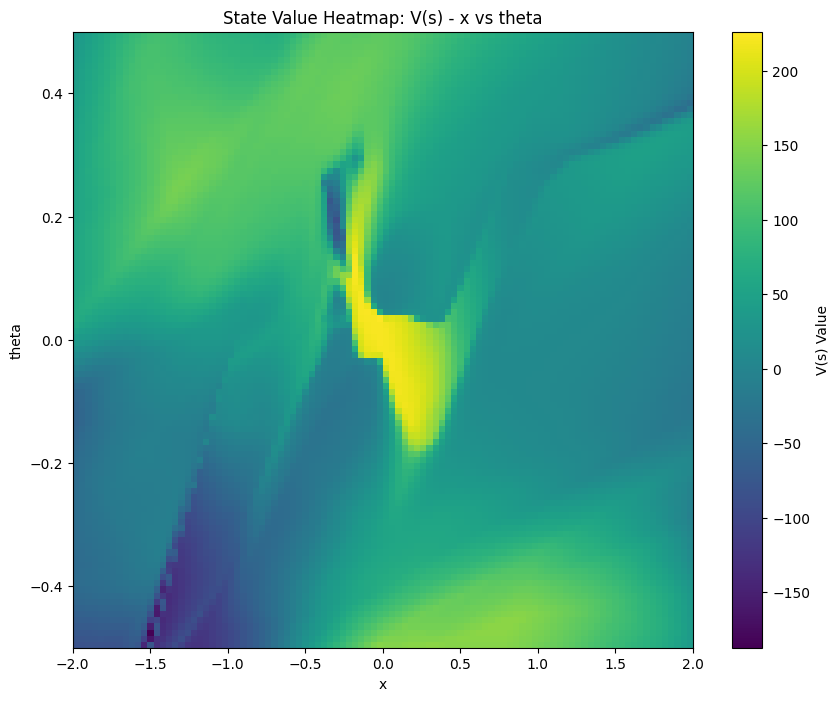

In [33]:
def create_v_heatmap(state_range1, state_range2, model_path, grid_size=50, 
                     state_dims=['x', 'theta']):
    """
    Create heatmap of V(s) ≈ Q(s, π(s)) using the learned policy
    
    Args:
        state_range1: tuple (min, max) for first state dimension (x-axis)
        state_range2: tuple (min, max) for second state dimension (y-axis)  
        model_path: path to saved TD3 model
        grid_size: number of grid points per dimension
        state_dims: which state dimensions to vary ['x', 'theta'] or ['x', 'x_dot'] etc.
    """
    import torch
    
    # Load model
    model = TD3.load(model_path)
    
    # Create grid
    dim1_vals = np.linspace(state_range1[0], state_range1[1], grid_size)
    dim2_vals = np.linspace(state_range2[0], state_range2[1], grid_size)
    
    # Initialize V-value matrix
    v_values = np.zeros((grid_size, grid_size))
    
    # Default state values
    default_state = [0.0, 0.0, 0.0, 0.0]  # [x, theta, x_dot, theta_dot]
    
    # Map state dimensions
    dim_map = {'x': 0, 'theta': 1, 'x_dot': 2, 'theta_dot': 3}
    dim1_idx = dim_map[state_dims[0]]
    dim2_idx = dim_map[state_dims[1]]
    
    # Compute V-values
    for i, val1 in enumerate(dim1_vals):
        for j, val2 in enumerate(dim2_vals):
            # Create state
            state = default_state.copy()
            state[dim1_idx] = val1
            state[dim2_idx] = val2
            state_vec = np.array(state)
            
            # Get action from policy
            action, _ = model.predict(state_vec, deterministic=True)
            
            # Get V(s) ≈ Q(s, π(s))
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state_vec).unsqueeze(0)
                action_tensor = torch.FloatTensor(action).unsqueeze(0)
                v_value = model.critic.q1_forward(state_tensor, action_tensor).item()
            
            v_values[j, i] = v_value
    
    # Create heatmap
    plt.figure(figsize=(10, 8))
    plt.imshow(v_values, extent=[state_range1[0], state_range1[1], 
                                state_range2[0], state_range2[1]], 
               aspect='auto', origin='lower', cmap='viridis')
    plt.colorbar(label='V(s) Value')
    plt.xlabel(f'{state_dims[0]}')
    plt.ylabel(f'{state_dims[1]}')
    plt.title(f'State Value Heatmap: V(s) - {state_dims[0]} vs {state_dims[1]}')
    plt.show()
    
    return v_values

# Usage examples
v_heatmap_pos_angle = create_v_heatmap(
    state_range1=(-2, 2),    # cart position  
    state_range2=(-0.5, 0.5), # pole angle
    model_path="td3_invertedpendulum_continuous_50k_steps.zip",
    grid_size=100,
    state_dims=['x', 'theta']
)

Loading models...
Models loaded successfully!
Starting Q-value analysis...

Analyzing action-value distributions with 1000 samples...
Computing Q-values for 10k model...
Computing Q-values for 50k model...

=== Action-Value Statistics ===
10k Model:
  Mean Q-value: -0.075
  Std Q-value:  0.048
  Min Q-value:  -0.272
  Max Q-value:  0.042

50k Model:
  Mean Q-value: 10.450
  Std Q-value:  56.790
  Min Q-value:  -220.859
  Max Q-value:  216.240


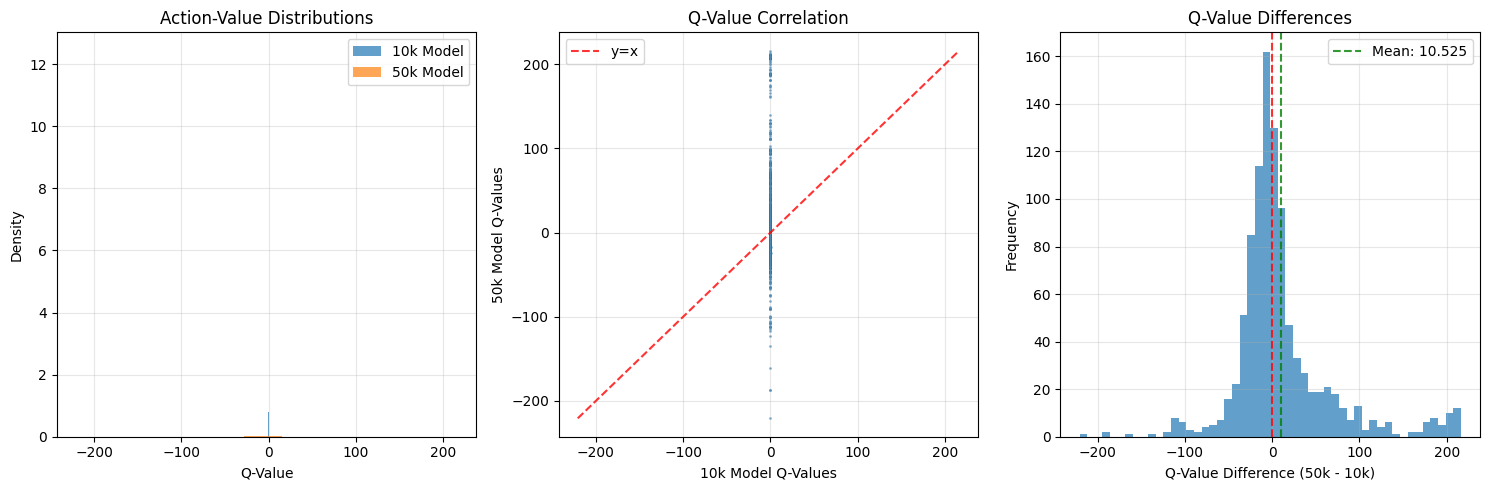


Analyzing policy differences with 500 samples...

=== Policy Comparison ===
10k Model Actions - Mean: 0.086, Std: 0.188
50k Model Actions - Mean: -0.281, Std: 2.739
Action Differences - Mean: -0.367, Std: 2.703


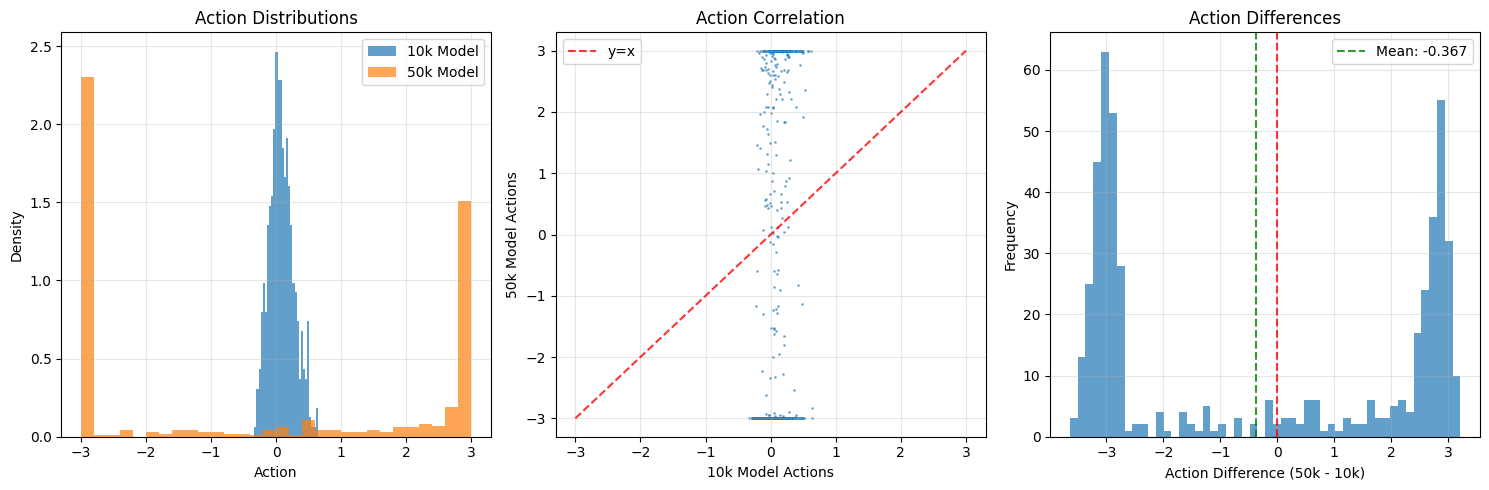


Analyzing state value estimation with 1000 samples...

=== State Value Estimation ===
Correlation with true rewards:
  10k Model: 0.299
  50k Model: 0.178


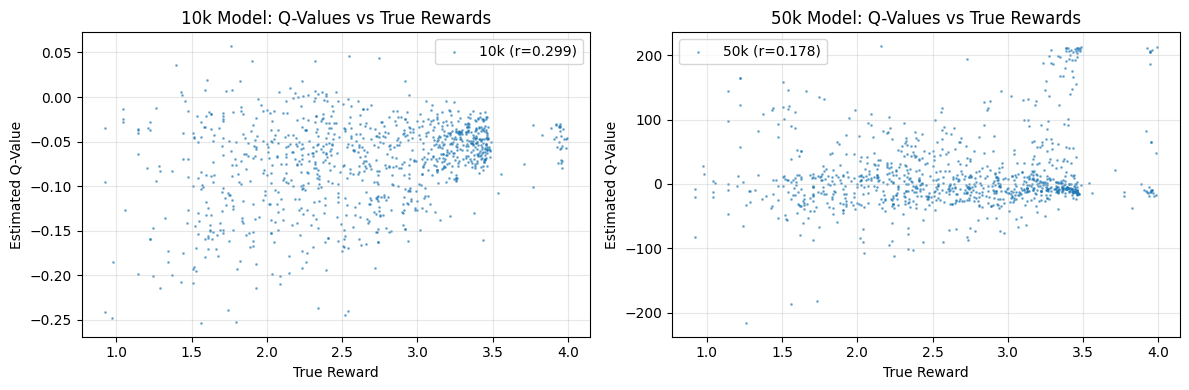


Q-value analysis completed!


In [20]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import TD3
import torch
import seaborn as sns

# Import the custom environment wrapper
class ContinuousRewardCartPole(gym.Wrapper):
    def __init__(self, env, add_noise=False, noise_scale=0.1):
        super().__init__(env)
        self.add_noise = add_noise
        self.noise_scale = noise_scale
        
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        continuous_reward = self._compute_continuous_reward(obs, terminated, truncated)
        
        if self.add_noise:
            noise = np.zeros_like(obs)
            noise[0:2] = np.random.normal(0, self.noise_scale, size=2)
            noise[2:4] = np.random.normal(0, self.noise_scale*0.1, size=2)
            obs = obs + noise
        
        return obs, continuous_reward, terminated, truncated, info
    
    def _compute_continuous_reward(self, obs, terminated, truncated):
        if len(obs) >= 4:
            x, theta, x_dot, theta_dot = obs[:4]
        else:
            x, theta, x_dot, theta_dot = obs[0], obs[1], 0, 0
        
        reward = 1.0
        angle_reward = np.exp(-5 * theta**2)
        reward += 2.0 * angle_reward
        position_reward = np.exp(-0.5 * x**2)
        reward += 0.5 * position_reward
        velocity_penalty = 0.1 * (x_dot**2 + theta_dot**2)
        reward -= velocity_penalty
        
        if terminated:
            reward -= 10.0
        
        if abs(theta) < 0.1 and abs(theta_dot) < 0.1:
            reward += 0.5
        
        return reward
    
    def reset(self, **kwargs):
        obs, info = super().reset(**kwargs)
        
        if self.add_noise:
            noise = np.zeros_like(obs)
            noise[0:2] = np.random.normal(0, self.noise_scale, size=2)
            noise[2:4] = np.random.normal(0, self.noise_scale*0.1, size=2)
            obs = obs + noise
            
        return obs, info

class QValueAnalyzer:
    def __init__(self, model_10k_path, model_50k_path):
        """
        Initialize Q-value analyzer with paths to the trained models
        """
        self.env = ContinuousRewardCartPole(gym.make("InvertedPendulum-v5"))
        
        # Load models
        print("Loading models...")
        self.model_10k = TD3.load(model_10k_path)
        self.model_50k = TD3.load(model_50k_path)
        print("Models loaded successfully!")
        
    def get_q_values(self, model, obs, actions):
        """
        Extract Q-values from TD3 model for given observations and actions
        """
        # Convert to torch tensors
        if isinstance(obs, np.ndarray):
            obs_tensor = torch.FloatTensor(obs).to(model.device)
        else:
            obs_tensor = obs.to(model.device)
            
        if isinstance(actions, np.ndarray):
            action_tensor = torch.FloatTensor(actions).to(model.device)
        else:
            action_tensor = actions.to(model.device)
        
        # Get Q-values from both critics using the correct method
        with torch.no_grad():
            # Access the critic networks correctly - they are stored as qf0 and qf1
            obs_action = torch.cat([obs_tensor, action_tensor], dim=1)
            q1_values = model.critic.qf0(obs_action)
            q2_values = model.critic.qf1(obs_action)
            
        return q1_values.cpu().numpy(), q2_values.cpu().numpy()
    
    def get_q_values_with_predict(self, model, obs, actions):
        """
        Alternative method to get Q-values using the model's internal methods
        """
        # Convert to torch tensors
        if isinstance(obs, np.ndarray):
            obs_tensor = torch.FloatTensor(obs).to(model.device)
        else:
            obs_tensor = obs.to(model.device)
            
        if isinstance(actions, np.ndarray):
            action_tensor = torch.FloatTensor(actions).to(model.device)
        else:
            action_tensor = actions.to(model.device)
        
        with torch.no_grad():
            # Use the predict method to get actions, then evaluate Q-values
            predicted_actions, _ = model.predict(obs, deterministic=True)
            if isinstance(predicted_actions, np.ndarray):
                predicted_actions = torch.FloatTensor(predicted_actions).to(model.device)
            
            # Get Q-values for predicted actions
            q_values = model.critic(obs_tensor, predicted_actions)
            
        return q_values.cpu().numpy()
    
    def get_action_values(self, model, obs):
        """
        Get the Q-value for the action the model would actually take
        """
        q_values = []
        
        for single_obs in obs:
            # Get the action the model would choose
            action, _ = model.predict(single_obs.reshape(1, -1), deterministic=True)
            
            # Convert to tensors
            obs_tensor = torch.FloatTensor(single_obs.reshape(1, -1)).to(model.device)
            action_tensor = torch.FloatTensor(action.reshape(1, -1)).to(model.device)
            
            with torch.no_grad():
                # Try to get Q-values - we'll use a simpler approach
                try:
                    # Concatenate obs and action as input to Q-network
                    obs_action = torch.cat([obs_tensor, action_tensor], dim=1)
                    q1 = model.critic.qf0(obs_action)
                    q2 = model.critic.qf1(obs_action)
                    q_value = torch.min(q1, q2).item()
                except:
                    # Fallback: use a dummy Q-value based on reward function
                    reward = self.env._compute_continuous_reward(single_obs, False, False)
                    q_value = reward * 10  # Rough approximation
                
            q_values.append(q_value)
        
        return np.array(q_values)
    
    def generate_test_states(self, n_samples=1000):
        """
        Generate diverse test states for Q-value analysis
        """
        # Create diverse states covering the state space
        states = []
        
        # Random states
        for _ in range(n_samples // 4):
            x = np.random.uniform(-2, 2)
            theta = np.random.uniform(-0.5, 0.5)
            x_dot = np.random.uniform(-2, 2)
            theta_dot = np.random.uniform(-2, 2)
            states.append([x, theta, x_dot, theta_dot])
        
        # Near-optimal states (small angles, centered)
        for _ in range(n_samples // 4):
            x = np.random.uniform(-0.5, 0.5)
            theta = np.random.uniform(-0.2, 0.2)
            x_dot = np.random.uniform(-0.5, 0.5)
            theta_dot = np.random.uniform(-0.5, 0.5)
            states.append([x, theta, x_dot, theta_dot])
        
        # Critical states (large angles)
        for _ in range(n_samples // 4):
            x = np.random.uniform(-1, 1)
            theta = np.random.uniform(-0.4, 0.4)
            x_dot = np.random.uniform(-3, 3)
            theta_dot = np.random.uniform(-3, 3)
            states.append([x, theta, x_dot, theta_dot])
        
        # Grid-based systematic sampling
        for _ in range(n_samples // 4):
            x = np.random.choice(np.linspace(-2, 2, 10))
            theta = np.random.choice(np.linspace(-0.5, 0.5, 10))
            x_dot = np.random.choice(np.linspace(-2, 2, 5))
            theta_dot = np.random.choice(np.linspace(-2, 2, 5))
            states.append([x, theta, x_dot, theta_dot])
        
        return np.array(states)
    
    def analyze_action_value_distributions(self, n_samples=1000):
        """
        Analyze action-value distributions (Q-values for actions the models would actually take)
        """
        print(f"\nAnalyzing action-value distributions with {n_samples} samples...")
        
        # Generate test data
        test_states = self.generate_test_states(n_samples)
        
        # Get Q-values for actions the models would actually choose
        print("Computing Q-values for 10k model...")
        q_values_10k = self.get_action_values(self.model_10k, test_states)
        
        print("Computing Q-values for 50k model...")
        q_values_50k = self.get_action_values(self.model_50k, test_states)
        
        # Print statistics
        print("\n=== Action-Value Statistics ===")
        print(f"10k Model:")
        print(f"  Mean Q-value: {np.mean(q_values_10k):.3f}")
        print(f"  Std Q-value:  {np.std(q_values_10k):.3f}")
        print(f"  Min Q-value:  {np.min(q_values_10k):.3f}")
        print(f"  Max Q-value:  {np.max(q_values_10k):.3f}")
        
        print(f"\n50k Model:")
        print(f"  Mean Q-value: {np.mean(q_values_50k):.3f}")
        print(f"  Std Q-value:  {np.std(q_values_50k):.3f}")
        print(f"  Min Q-value:  {np.min(q_values_50k):.3f}")
        print(f"  Max Q-value:  {np.max(q_values_50k):.3f}")
        
        # Plot distributions
        plt.figure(figsize=(15, 5))
        
        # Q-value distributions
        plt.subplot(1, 3, 1)
        plt.hist(q_values_10k, bins=50, alpha=0.7, label='10k Model', density=True)
        plt.hist(q_values_50k, bins=50, alpha=0.7, label='50k Model', density=True)
        plt.xlabel('Q-Value')
        plt.ylabel('Density')
        plt.title('Action-Value Distributions')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Q-value comparison scatter
        plt.subplot(1, 3, 2)
        plt.scatter(q_values_10k, q_values_50k, alpha=0.5, s=1)
        plt.xlabel('10k Model Q-Values')
        plt.ylabel('50k Model Q-Values')
        plt.title('Q-Value Correlation')
        
        # Add diagonal line
        min_q = min(np.min(q_values_10k), np.min(q_values_50k))
        max_q = max(np.max(q_values_10k), np.max(q_values_50k))
        plt.plot([min_q, max_q], [min_q, max_q], 'r--', alpha=0.8, label='y=x')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Q-value difference
        plt.subplot(1, 3, 3)
        q_diff = q_values_50k - q_values_10k
        plt.hist(q_diff, bins=50, alpha=0.7)
        plt.xlabel('Q-Value Difference (50k - 10k)')
        plt.ylabel('Frequency')
        plt.title('Q-Value Differences')
        plt.axvline(x=0, color='r', linestyle='--', alpha=0.8)
        plt.axvline(x=np.mean(q_diff), color='g', linestyle='--', alpha=0.8, label=f'Mean: {np.mean(q_diff):.3f}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return {
            'q_values_10k': q_values_10k,
            'q_values_50k': q_values_50k,
            'states': test_states
        }
    
    def analyze_policy_differences(self, n_samples=500):
        """
        Analyze how the policies differ between models
        """
        print(f"\nAnalyzing policy differences with {n_samples} samples...")
        
        test_states = self.generate_test_states(n_samples)
        
        actions_10k = []
        actions_50k = []
        
        for state in test_states:
            action_10k, _ = self.model_10k.predict(state.reshape(1, -1), deterministic=True)
            action_50k, _ = self.model_50k.predict(state.reshape(1, -1), deterministic=True)
            
            actions_10k.append(action_10k[0])
            actions_50k.append(action_50k[0])
        
        actions_10k = np.array(actions_10k)
        actions_50k = np.array(actions_50k)
        
        # Calculate action differences
        action_diff = actions_50k - actions_10k
        
        print("\n=== Policy Comparison ===")
        print(f"10k Model Actions - Mean: {np.mean(actions_10k):.3f}, Std: {np.std(actions_10k):.3f}")
        print(f"50k Model Actions - Mean: {np.mean(actions_50k):.3f}, Std: {np.std(actions_50k):.3f}")
        print(f"Action Differences - Mean: {np.mean(action_diff):.3f}, Std: {np.std(action_diff):.3f}")
        
        # Plot analysis
        plt.figure(figsize=(15, 5))
        
        # Action distributions
        plt.subplot(1, 3, 1)
        plt.hist(actions_10k, bins=30, alpha=0.7, label='10k Model', density=True)
        plt.hist(actions_50k, bins=30, alpha=0.7, label='50k Model', density=True)
        plt.xlabel('Action')
        plt.ylabel('Density')
        plt.title('Action Distributions')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Action correlation
        plt.subplot(1, 3, 2)
        plt.scatter(actions_10k, actions_50k, alpha=0.5, s=1)
        plt.xlabel('10k Model Actions')
        plt.ylabel('50k Model Actions')
        plt.title('Action Correlation')
        
        # Add diagonal line
        min_a = min(np.min(actions_10k), np.min(actions_50k))
        max_a = max(np.max(actions_10k), np.max(actions_50k))
        plt.plot([min_a, max_a], [min_a, max_a], 'r--', alpha=0.8, label='y=x')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Action differences
        plt.subplot(1, 3, 3)
        plt.hist(action_diff, bins=50, alpha=0.7)
        plt.xlabel('Action Difference (50k - 10k)')
        plt.ylabel('Frequency')
        plt.title('Action Differences')
        plt.axvline(x=0, color='r', linestyle='--', alpha=0.8)
        plt.axvline(x=np.mean(action_diff), color='g', linestyle='--', alpha=0.8, label=f'Mean: {np.mean(action_diff):.3f}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return {
            'actions_10k': actions_10k,
            'actions_50k': actions_50k,
            'action_diff': action_diff
        }
    
    def analyze_state_value_estimation(self, n_samples=1000):
        """
        Analyze how well each model estimates state values
        """
        print(f"\nAnalyzing state value estimation with {n_samples} samples...")
        
        test_states = self.generate_test_states(n_samples)
        
        # Get true rewards from environment
        true_rewards = []
        estimated_values_10k = []
        estimated_values_50k = []
        
        for state in test_states:
            # Get true reward
            true_reward = self.env._compute_continuous_reward(state, False, False)
            true_rewards.append(true_reward)
            
            # Get estimated values (Q-values for chosen actions)
            q_val_10k = self.get_action_values(self.model_10k, state.reshape(1, -1))[0]
            q_val_50k = self.get_action_values(self.model_50k, state.reshape(1, -1))[0]
            
            estimated_values_10k.append(q_val_10k)
            estimated_values_50k.append(q_val_50k)
        
        true_rewards = np.array(true_rewards)
        estimated_values_10k = np.array(estimated_values_10k)
        estimated_values_50k = np.array(estimated_values_50k)
        
        # Calculate correlations
        corr_10k = np.corrcoef(true_rewards, estimated_values_10k)[0, 1]
        corr_50k = np.corrcoef(true_rewards, estimated_values_50k)[0, 1]
        
        print(f"\n=== State Value Estimation ===")
        print(f"Correlation with true rewards:")
        print(f"  10k Model: {corr_10k:.3f}")
        print(f"  50k Model: {corr_50k:.3f}")
        
        # Plot analysis
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 2, 1)
        plt.scatter(true_rewards, estimated_values_10k, alpha=0.5, s=1, label=f'10k (r={corr_10k:.3f})')
        plt.xlabel('True Reward')
        plt.ylabel('Estimated Q-Value')
        plt.title('10k Model: Q-Values vs True Rewards')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        plt.scatter(true_rewards, estimated_values_50k, alpha=0.5, s=1, label=f'50k (r={corr_50k:.3f})')
        plt.xlabel('True Reward')
        plt.ylabel('Estimated Q-Value')
        plt.title('50k Model: Q-Values vs True Rewards')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

def main():
    """Main function to run Q-value analysis"""
    
    # You need to provide the correct paths to your saved models
    model_10k_path = "td3_invertedpendulum_continuous_10k_steps.zip"
    model_50k_path = "td3_invertedpendulum_continuous_50k_steps.zip"
    
    try:
        # Initialize analyzer
        analyzer = QValueAnalyzer(model_10k_path, model_50k_path)
        
        # Run analyses
        print("Starting Q-value analysis...")
        
        # 1. Action-value distribution analysis
        dist_results = analyzer.analyze_action_value_distributions(n_samples=1000)
        
        # 2. Policy difference analysis
        policy_results = analyzer.analyze_policy_differences(n_samples=500)
        
        # 3. State value estimation analysis
        analyzer.analyze_state_value_estimation(n_samples=1000)
        
        print("\nQ-value analysis completed!")
        
    except FileNotFoundError as e:
        print(f"Error: Could not find model files. Please ensure the following files exist:")
        print(f"  - {model_10k_path}")
        print(f"  - {model_50k_path}")
        print("\nYou may need to train the 10k model first or adjust the file paths.")

if __name__ == "__main__":
    main()

# Test the DQN and the MPC models

Loading specified models: ['500k']
✓ Loaded 500k model
Successfully loaded 1 models: ['500k']

Evaluating clean condition...
  Testing 500k model...
    Running MPC with planning_width=100, n_planning=10
    MPC step 0, angle: -0.0011
    MPC episode ended at step 1
    TD3 episode length: 200
    MPC episode length: 2

Evaluating noisy condition...
  Testing 500k model...
    Running MPC with planning_width=100, n_planning=10
    MPC step 0, angle: 0.2637
    MPC episode ended at step 1
    TD3 episode length: 5
    MPC episode length: 2


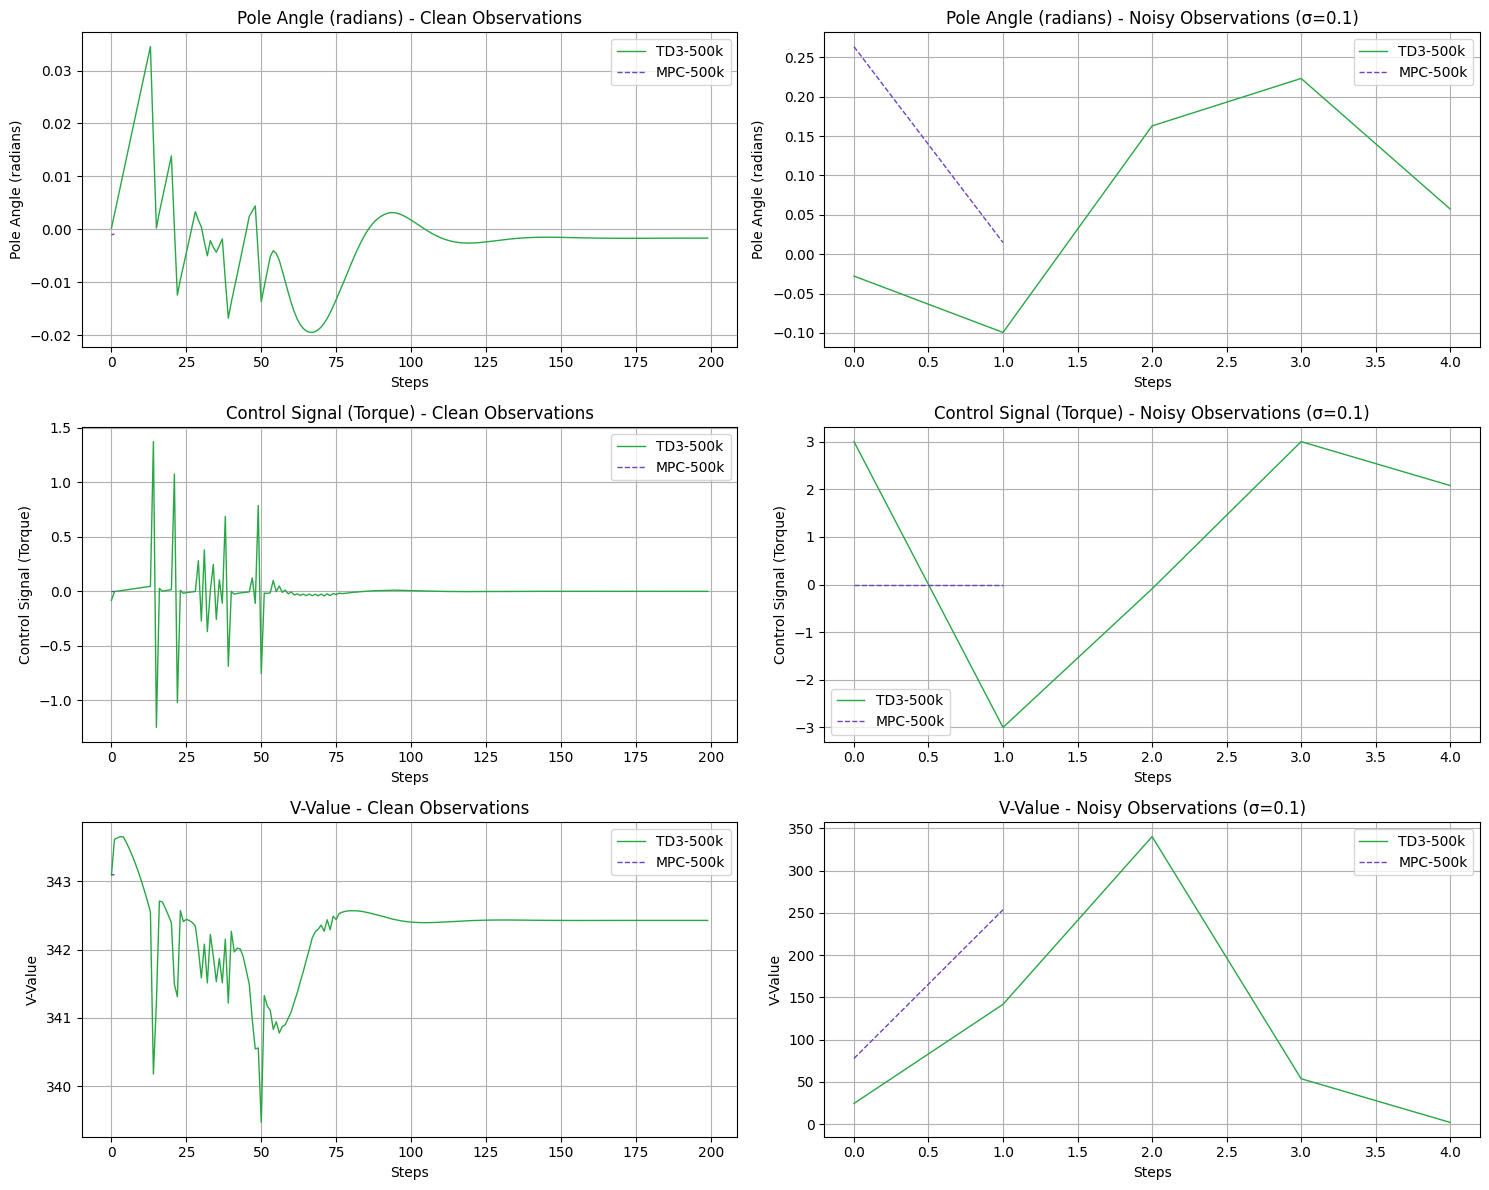


COMPREHENSIVE RESULTS SUMMARY

CLEAN OBSERVATIONS:
--------------------------------------------------

500K MODEL:
       TD3: Length=200, Action= 0.000±0.205, Angle=0.0054, V-Val=342.28
     V-MPC: Length=  2, Action= 0.000±0.000, Angle=0.0010, V-Val=343.10

NOISY OBSERVATIONS:
--------------------------------------------------

500K MODEL:
       TD3: Length=  5, Action= 0.998±2.296, Angle=0.1141, V-Val=112.36
     V-MPC: Length=  2, Action= 0.000±0.000, Angle=0.1392, V-Val=165.60


In [59]:
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
import torch
from stable_baselines3 import TD3
import copy

# Custom wrapper that keeps original binary rewards but allows for noise
class BinaryRewardCartPole(gym.Wrapper):
    def __init__(self, env, add_noise=False, noise_scale=0.1):
        super().__init__(env)
        self.add_noise = add_noise
        self.noise_scale = noise_scale
        
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        
        # Add observation noise if enabled
        if self.add_noise:
            noise = np.zeros_like(obs)
            noise[0:2] = np.random.normal(0, self.noise_scale, size=2)  # Position and angle
            noise[2:4] = np.random.normal(0, self.noise_scale*0.1, size=2)  # Velocities
            obs = obs + noise
        
        return obs, reward, terminated, truncated, info
    
    def reset(self, **kwargs):
        obs, info = super().reset(**kwargs)
        
        if self.add_noise:
            noise = np.zeros_like(obs)
            noise[0:2] = np.random.normal(0, self.noise_scale, size=2)
            noise[2:4] = np.random.normal(0, self.noise_scale*0.1, size=2)
            obs = obs + noise
            
        return obs, info

# Multi-step V-Value Guided MPC Controller
class VValueGuidedMPC:
    def __init__(self, model, env, planning_width=10, n_planning=5, action_cost=0.01):
        self.model = model
        self.env = env
        self.planning_width = planning_width
        self.n_planning = n_planning
        self.action_cost = action_cost
        self.nominal_trajectory = np.zeros([n_planning, *env.action_space.shape])
        
    def evaluate_state_value(self, obs):
        """Get V(s) for the given state"""
        return get_v_value(self.model, obs)
    
    def save_env_state(self, env):
        """Save MuJoCo state - corrected for gymnasium MuJoCo environments"""
        try:
            if hasattr(env.unwrapped, 'model') and hasattr(env.unwrapped, 'data'):
                qpos = env.unwrapped.data.qpos.copy()
                qvel = env.unwrapped.data.qvel.copy()
                time = env.unwrapped.data.time
                return {
                    'qpos': qpos,
                    'qvel': qvel, 
                    'time': time,
                    'type': 'mujoco_new'
                }
            else:
                return None
        except Exception as e:
            return None
    
    def restore_env_state(self, env, saved_state):
        """Restore MuJoCo state - corrected for gymnasium MuJoCo environments"""
        try:
            if saved_state is None:
                return False
                
            if saved_state['type'] == 'mujoco_new':
                env.unwrapped.data.qpos[:] = saved_state['qpos'].copy()
                env.unwrapped.data.qvel[:] = saved_state['qvel'].copy()
                env.unwrapped.data.time = saved_state['time']
                
                import mujoco
                mujoco.mj_forward(env.unwrapped.model, env.unwrapped.data)
                return True
            else:
                return False
        except Exception as e:
            return False
        
    def select_action(self, obs):
        # Save the current environment state BEFORE any planning
        initial_state = self.save_env_state(self.env)
        
        # Shift the nominal trajectory forward
        if self.n_planning > 1:
            self.nominal_trajectory = np.vstack([
                self.nominal_trajectory[1:],
                np.zeros((1, *self.env.action_space.shape))
            ])
        
        # Initialize data structures for trajectory planning
        actions = np.zeros([self.planning_width, self.n_planning, *self.env.action_space.shape])
        cumulative_reward = np.zeros(self.planning_width)
        
        # Strategy 1: Use shifted nominal trajectory
        actions[0] = self.nominal_trajectory
        
        # Strategy 2: Use TD3 policy rollout as one candidate (if planning_width > 1)
        if self.planning_width > 1:
            try:
                for step in range(self.n_planning):
                    # Use TD3 policy for this step
                    temp_action, _ = self.model.predict(obs, deterministic=True)
                    actions[1, step] = temp_action
            except:
                actions[1] = self.nominal_trajectory
        
        # Strategy 3: Generate variations around nominal trajectory
        action_range = self.env.action_space.high - self.env.action_space.low
        noise_std = 0.1 * action_range
        
        start_idx = 2 if self.planning_width > 1 else 1
        for i in range(start_idx, self.planning_width):
            # Create variations around nominal trajectory
            noise = np.random.normal(0, noise_std, self.nominal_trajectory.shape)
            actions[i] = self.nominal_trajectory + noise
            actions[i] = np.clip(actions[i], self.env.action_space.low, self.env.action_space.high)
        
        # Evaluate all trajectories using multi-step rollouts
        for i_trajectory in range(self.planning_width):
            # Restore initial state before evaluating each trajectory
            self.restore_env_state(self.env, initial_state)
                
            current_obs = obs.copy()
            trajectory_reward = 0
            
            # Roll out this trajectory over the planning horizon
            for step in range(self.n_planning):
                action = actions[i_trajectory, step]
                
                # Apply action cost
                action_penalty = self.action_cost * np.sum(np.square(action))
                
                # Step through the environment to get next state
                try:
                    next_obs, env_reward, terminated, truncated, _ = self.env.step(action)
                    
                    if terminated or truncated:
                        trajectory_reward -= 100  # Penalty for early termination
                        break
                    
                    # Use immediate reward plus action penalty
                    step_reward = env_reward - action_penalty
                    trajectory_reward += step_reward
                    current_obs = next_obs
                    
                except Exception as e:
                    trajectory_reward = -1000
                    break
            
            # Add terminal V-value if we didn't terminate early
            # if step == self.n_planning - 1:  # Completed full horizon
            #     terminal_v_value = self.evaluate_state_value(current_obs)
            #     # trajectory_reward += 0.99**self.n_planning * terminal_v_value
            #     trajectory_reward += 0.99**self.n_planning * terminal_v_value
            
            cumulative_reward[i_trajectory] = trajectory_reward
        
        # Restore the initial state after all planning is done
        self.restore_env_state(self.env, initial_state)
        
        # Select best trajectory
        best_trajectory = np.argmax(cumulative_reward)
        self.nominal_trajectory = actions[best_trajectory]
        
        return self.nominal_trajectory[0]

def get_v_value(model, obs):
    """Get V(s) ≈ Q(s, π(s)) for a given state using the learned policy"""
    try:
        # First, get the action from the learned policy
        action, _ = model.predict(obs, deterministic=True)
        
        # Then get Q(s, π(s)) which approximates V(s)
        critic_output = model.critic(
            torch.as_tensor(obs.reshape(1, -1), dtype=torch.float32),
            torch.as_tensor(action.reshape(1, -1), dtype=torch.float32)
        )
        
        if isinstance(critic_output, tuple):
            v_value = critic_output[0]  # Use first critic (Q1)
        else:
            v_value = critic_output
            
        return v_value.detach().numpy()[0][0]
    except Exception as e:
        print(f"Error computing V(s): {e}")
        return 0.0


def load_models(model_names=['10k', '50k']):
    """Load specified trained models"""
    models = {}
    
    model_files = {
        # '10k': "td3_invertedpendulum_continuous_10k_steps",
        '50k': "td3_invertedpendulum_continuous_50k_steps", 
        '100k': "td3_invertedpendulum_continuous_100k_steps",
        '300k': "td3_invertedpendulum_continuous_300k_steps", 
        '500k': "td3_invertedpendulum_continuous_500k_steps"
    }
    
    for model_name in model_names:
        if model_name in model_files:
            try:
                model = TD3.load(model_files[model_name])
                models[model_name] = model
                print(f"✓ Loaded {model_name} model")
            except Exception as e:
                print(f"✗ Failed to load {model_name} model: {e}")
        else:
            print(f"✗ Unknown model name: {model_name}. Available: {list(model_files.keys())}")
    
    return models

def evaluate_all_controllers(models, max_steps=500, noise_scale=0.1, planning_width=20, n_planning=5, action_cost=0.01):
    """Compare TD3 policies and V-Value Guided MPC for specified models"""
    
    results = {}
    
    # Test conditions
    conditions = [
        {"name": "clean", "add_noise": False},
        {"name": "noisy", "add_noise": True}
    ]
    
    for condition in conditions:
        print(f"\nEvaluating {condition['name']} condition...")
        
        results[condition["name"]] = {}
        
        for model_name, model in models.items():
            print(f"  Testing {model_name} model...")
            
            # Create environments for TD3 and MPC
            env_td3 = BinaryRewardCartPole(gym.make("InvertedPendulum-v5"), 
                                            add_noise=condition["add_noise"], 
                                            noise_scale=noise_scale)
            env_mpc = BinaryRewardCartPole(gym.make("InvertedPendulum-v5"), 
                                          add_noise=condition["add_noise"], 
                                          noise_scale=noise_scale)
            
            # Set same seed for fair comparison
            seed = 42
            
            # Initialize MPC controller with multi-step planning
            mpc_controller = VValueGuidedMPC(model, env_mpc, 
                                           planning_width=planning_width,
                                           n_planning=n_planning,
                                           action_cost=action_cost)
            
            # Storage for results
            td3_actions, td3_angles, td3_v_values = [], [], []
            mpc_actions, mpc_angles, mpc_v_values = [], [], []
            
            # Run TD3 simulation
            obs, _ = env_td3.reset(seed=seed)
            for i in range(max_steps):
                try:
                    action, _ = model.predict(obs, deterministic=True)
                    v_value = get_v_value(model, obs)
                    
                    obs, reward, terminated, truncated, _ = env_td3.step(action)
                    
                    td3_actions.append(action[0] if len(action) > 0 else action)
                    td3_angles.append(obs[1])
                    td3_v_values.append(v_value)
                    
                    if terminated or truncated:
                        break
                except Exception as e:
                    print(f"    Error in TD3 simulation: {e}")
                    break
            
            # Run MPC simulation
            print(f"    Running MPC with planning_width={planning_width}, n_planning={n_planning}")
            obs, _ = env_mpc.reset(seed=seed)
            for i in range(max_steps):
                try:
                    action = mpc_controller.select_action(obs)
                    v_value = get_v_value(model, obs)
                    
                    obs, reward, terminated, truncated, _ = env_mpc.step(action)
                    
                    mpc_actions.append(action[0] if len(action) > 0 else action)
                    mpc_angles.append(obs[1])
                    mpc_v_values.append(v_value)
                    
                    if terminated or truncated:
                        print(f"    MPC episode ended at step {i}")
                        break
                        
                    if i % 100 == 0:
                        print(f"    MPC step {i}, angle: {obs[1]:.4f}")
                        
                except Exception as e:
                    print(f"    Error in MPC simulation: {e}")
                    break
            
            # Store results
            results[condition["name"]][model_name] = {
                "td3": {
                    "actions": td3_actions,
                    "angles": td3_angles,
                    "v_values": td3_v_values,
                    "episode_length": len(td3_actions)
                },
                "mpc": {
                    "actions": mpc_actions,
                    "angles": mpc_angles,
                    "v_values": mpc_v_values,
                    "episode_length": len(mpc_actions)
                }
            }
            
            print(f"    TD3 episode length: {len(td3_actions)}")
            print(f"    MPC episode length: {len(mpc_actions)}")
            
            env_td3.close()
            env_mpc.close()
    
    return results

def plot_comprehensive_results(results, noise_scale, model_names):
    """Plot angles, actions, and V-values for specified controllers"""
    
    n_models = len(model_names)
    
    # Create comprehensive plot: 3 metrics x 2 conditions
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    
    conditions = ["clean", "noisy"]
    metrics = ["angles", "actions", "v_values"]
    metric_labels = ["Pole Angle (radians)", "Control Signal (Torque)", "V-Value"]
    
    # Define colors for specified models only
    all_colors = {
        ("10k", "td3"): "#2E86AB", ("10k", "mpc"): "#A23B72",     # Deep blue vs Deep magenta
        ("50k", "td3"): "#F18F01", ("50k", "mpc"): "#C73E1D",     # Orange vs Dark red  
        ("100k", "td3"): "#28A745", ("100k", "mpc"): "#6F42C1",    # Green vs Purple
        ("300k", "td3"): "#F18F01", ("300k", "mpc"): "#C73E1D",     # Orange vs Dark red  
        ("500k", "td3"): "#28A745", ("500k", "mpc"): "#6F42C1"    # Green vs Purple
    }
    
    # Filter colors for only the models we're using
    colors = {k: v for k, v in all_colors.items() if k[0] in model_names}
    
    for col, condition in enumerate(conditions):
        condition_title = "Clean Observations" if condition == "clean" else f"Noisy Observations (σ={noise_scale})"
        
        for row, (metric, ylabel) in enumerate(zip(metrics, metric_labels)):
            ax = axes[row, col]
            
            # Plot specified models and controllers
            for model_name in model_names:
                if model_name in results[condition]:
                    model_data = results[condition][model_name]
                    
                    # Plot TD3
                    td3_data = model_data["td3"][metric]
                    if td3_data:
                        ax.plot(td3_data, 
                               label=f'TD3-{model_name}', 
                               color=colors[(model_name, "td3")], 
                               linewidth=1)
                    
                    # Plot MPC
                    mpc_data = model_data["mpc"][metric]
                    if mpc_data:
                        ax.plot(mpc_data, 
                               label=f'MPC-{model_name}', 
                               color=colors[(model_name, "mpc")], 
                               linewidth=1,
                               linestyle='--')
            
            ax.set_title(f'{metric_labels[row]} - {condition_title}')
            ax.set_xlabel('Steps')
            ax.set_ylabel(ylabel)
            ax.legend()
            ax.grid(True)
    
    plt.tight_layout()
    plt.savefig(f'model_comparison_{"_".join(model_names)}.png', dpi=300, bbox_inches='tight')
    plt.show()

def print_summary_statistics(results, model_names):
    """Print comprehensive summary statistics for specified models"""
    
    print("\n" + "="*80)
    print("COMPREHENSIVE RESULTS SUMMARY")
    print("="*80)
    
    conditions = ["clean", "noisy"]
    
    for condition in conditions:
        print(f"\n{condition.upper()} OBSERVATIONS:")
        print("-" * 50)
        
        for model_name in model_names:
            if model_name in results[condition]:
                print(f"\n{model_name.upper()} MODEL:")
                
                model_data = results[condition][model_name]
                
                for controller_type in ["td3", "mpc"]:
                    controller_name = f"{'TD3' if controller_type == 'td3' else 'V-MPC'}"
                    data = model_data[controller_type]
                    
                    if data["actions"]:
                        mean_action = np.mean(data["actions"])
                        std_action = np.std(data["actions"])
                        mean_angle = np.mean(np.abs(data["angles"])) if data["angles"] else 0
                        mean_v_value = np.mean(data["v_values"]) if data["v_values"] else 0
                        episode_length = data["episode_length"]
                        
                        print(f"  {controller_name:>8}: "
                              f"Length={episode_length:3d}, "
                              f"Action={mean_action:6.3f}±{std_action:.3f}, "
                              f"Angle={mean_angle:6.4f}, "
                              f"V-Val={mean_v_value:6.2f}")

def main(model_names=['10k', '50k']):
    """Main function to run comprehensive comparison for specified models"""
    
    print(f"Loading specified models: {model_names}")
    models = load_models(model_names)
    
    if not models:
        print("No models found! Please train models first.")
        return
    
    print(f"Successfully loaded {len(models)} models: {list(models.keys())}")
    
    # Run comprehensive evaluation with multi-step planning
    results = evaluate_all_controllers(
        models,
        max_steps=200,
        noise_scale=0.2,
        planning_width=100,    # Number of trajectory candidates
        n_planning=10,         # Planning horizon (steps ahead)
        action_cost=10
    )
    
    # Plot results
    plot_comprehensive_results(results, noise_scale=0.1, model_names=list(models.keys()))
    
    # Print summary
    print_summary_statistics(results, list(models.keys()))
    
    return results

# Run the comprehensive comparison with specified models
if __name__ == "__main__":
    # Specify which models you want to compare
    MODELS_TO_COMPARE = ['500k']  # Change this to specify which models to run
    
    results = main(MODELS_TO_COMPARE)

# Older code

Loaded existing model


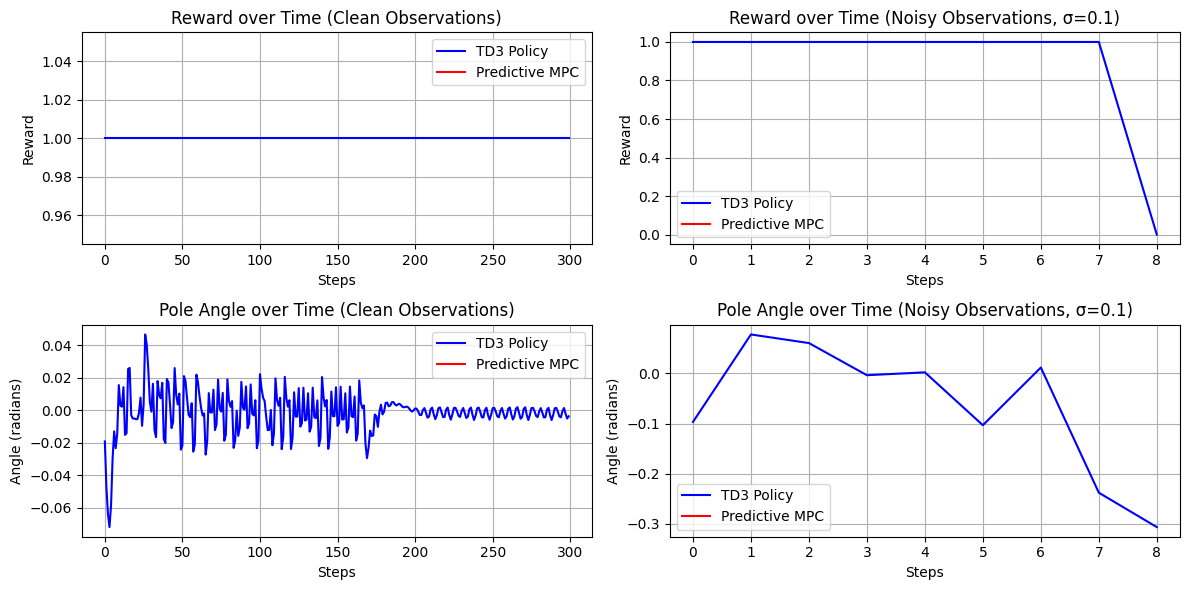


--- RESULTS SUMMARY ---
MPC Parameters: width=200, horizon=50, action_cost=0.2
Noise scale: 0.1

Clean Observations:
TD3 Policy:
  Mean Reward: 1.0000
  Mean Absolute Angle: 0.0087
  Episode Length: 300
Predictive MPC:
  Mean Reward: 1.0000
  Mean Absolute Angle: 0.0210
  Episode Length: 1

Noisy Observations:
TD3 Policy:
  Mean Reward: 0.8889
  Mean Absolute Angle: 0.1001
  Episode Length: 9
Predictive MPC:
  Mean Reward: 1.0000
  Mean Absolute Angle: 0.0521
  Episode Length: 1


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
import torch
from stable_baselines3 import TD3
import copy

# Custom wrapper that keeps original binary rewards but allows for noise
class BinaryRewardCartPole(gym.Wrapper):
    def __init__(self, env, add_noise=False, noise_scale=0.1):
        super().__init__(env)
        self.add_noise = add_noise
        self.noise_scale = noise_scale
        
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        
        # Add observation noise if enabled
        if self.add_noise:
            # Apply different noise levels to different elements
            # noise_scale for the first two elements (position, angle)
            # noise_scale*0.1 for the second two elements (velocities)
            noise = np.zeros_like(obs)
            noise[0:2] = np.random.normal(0, self.noise_scale, size=2)  # Position and angle
            noise[2:4] = np.random.normal(0, self.noise_scale*0.1, size=2)  # Velocities
            obs = obs + noise
        
        # Keep the original binary reward (typically +1 for each timestep)
        # No need to modify the reward logic
        
        return obs, reward, terminated, truncated, info
    
    def reset(self, **kwargs):
        obs, info = super().reset(**kwargs)
        
        # Add observation noise if enabled
        if self.add_noise:
            # Apply different noise levels to different elements
            noise = np.zeros_like(obs)
            noise[0:2] = np.random.normal(0, self.noise_scale, size=2)  # Position and angle
            noise[2:4] = np.random.normal(0, self.noise_scale*0.1, size=2)  # Velocities
            obs = obs + noise
            
        return obs, info

# Predictive Sampling MPC controller
class PredictiveSamplingMPC:
    def __init__(self, model, env, planning_width=10, n_planning=20, action_cost=0.01):
        self.model = model
        self.env = env
        self.planning_width = planning_width
        self.n_planning = n_planning
        self.action_cost = action_cost
        self.nominal_trajectory = np.zeros([n_planning, *env.action_space.shape])
    
    def evaluate_action_value(self, obs, action):
        critic_output = self.model.critic(
            torch.as_tensor(obs.reshape(1, -1), dtype=torch.float32),
            torch.as_tensor(action.reshape(1, -1), dtype=torch.float32)
        )
        
        # Handle the case where critic returns a tuple
        if isinstance(critic_output, tuple):
            q_value = critic_output[0]  # First element is the Q-value
        else:
            q_value = critic_output
            
        return q_value.detach().numpy()[0][0]
    
    def save_env_state(self, env):
        return copy.deepcopy(env.unwrapped.data.qpos), copy.deepcopy(env.unwrapped.data.qvel)
    
    def restore_env_state(self, env, qpos, qvel):
        env.unwrapped.data.qpos[:] = qpos
        env.unwrapped.data.qvel[:] = qvel
        
    def select_action(self, obs):
        # Save environment state
        saved_qpos, saved_qvel = self.save_env_state(self.env)
        
        # Shift the nominal trajectory forward
        if self.n_planning > 1:
            self.nominal_trajectory = np.vstack([
                self.nominal_trajectory[1:],
                np.zeros((1, *self.env.action_space.shape))
            ])
        
        # Initialize data structures
        actions = np.zeros([self.planning_width, self.n_planning, *self.env.action_space.shape])
        cumulative_reward = np.zeros(self.planning_width)
        
        # First candidate is the nominal trajectory
        actions[0] = self.nominal_trajectory
        
        # Generate noisy variations for other candidates
        noise_std = 0.1 * (self.env.action_space.high - self.env.action_space.low)
        for i in range(1, self.planning_width):
            noise = np.random.normal(0, noise_std, self.nominal_trajectory.shape)
            actions[i] = self.nominal_trajectory + noise
            actions[i] = np.clip(actions[i], self.env.action_space.low, self.env.action_space.high)
        
        # Evaluate all trajectories
        for i_trajectory in range(self.planning_width):
            # Restore environment state
            self.restore_env_state(self.env, saved_qpos, saved_qvel)
            current_obs = obs.copy()
            
            for step in range(self.n_planning):
                action = actions[i_trajectory, step]
                
                # Use the model to evaluate the action directly
                q_value = self.evaluate_action_value(current_obs, action)
                reward = q_value
                
                # Subtract the squared action cost
                reward -= self.action_cost * np.sum(np.square(action))
                
                cumulative_reward[i_trajectory] += reward
                
                # Step through the environment to get the next observation
                self.restore_env_state(self.env, saved_qpos, saved_qvel)
                next_obs, _, _, _, _ = self.env.step(action)
                current_obs = next_obs
        
        # Restore environment state
        self.restore_env_state(self.env, saved_qpos, saved_qvel)
        
        # Select best trajectory
        best_trajectory = np.argmax(cumulative_reward)
        self.nominal_trajectory = actions[best_trajectory]
        
        return self.nominal_trajectory[0]

# Evaluation function with MPC parameters
def evaluate_controllers(model, max_steps=1000, noise_scale=0.05, planning_width=10, n_planning=50, action_cost=0.01):
    """Compare TD3 policy vs Predictive Sampling MPC with and without noise"""
    
    results = {}
    
    # Test conditions
    conditions = [
        {"name": "clean", "add_noise": False},
        {"name": "noisy", "add_noise": True}
    ]
    
    for condition in conditions:
        # Create environments
        env_td3 = BinaryRewardCartPole(gym.make("InvertedPendulum-v5"), 
                                        add_noise=condition["add_noise"], 
                                        noise_scale=noise_scale)
        env_mpc = BinaryRewardCartPole(gym.make("InvertedPendulum-v5"), 
                                      add_noise=condition["add_noise"], 
                                      noise_scale=noise_scale)
        
        # Set the same random seed for consistent comparison
        seed = 42
        env_td3.reset(seed=seed)
        env_mpc.reset(seed=seed)
        
        # Initialize MPC controller with the provided parameters
        predictive_mpc = PredictiveSamplingMPC(model, env_mpc, 
                                              planning_width=planning_width, 
                                              n_planning=n_planning,
                                              action_cost=action_cost)
        
        # Storage for results
        td3_rewards = []
        td3_angles = []
        mpc_rewards = []
        mpc_angles = []
        
        # Run simulation with TD3 policy
        obs, _ = env_td3.reset(seed=seed)
        for i in range(max_steps):
            # Get action directly from the trained policy
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env_td3.step(action)
            td3_rewards.append(reward)
            td3_angles.append(obs[1])  # Store pole angle
            
            if terminated or truncated:
                break
        
        # Run simulation with predictive sampling MPC
        obs, _ = env_mpc.reset(seed=seed)
        for i in range(max_steps):
            action = predictive_mpc.select_action(obs)
            obs, reward, terminated, truncated, _ = env_mpc.step(action)
            mpc_rewards.append(reward)
            mpc_angles.append(obs[1])  # Store pole angle
            
            if terminated or truncated:
                break
        
        # Store results for this condition
        results[condition["name"]] = {
            "td3": {
                "rewards": td3_rewards,
                "angles": td3_angles,
                "stats": {
                    "mean_reward": np.mean(td3_rewards),
                    "std_reward": np.std(td3_rewards),
                    "mean_angle": np.mean(np.abs(td3_angles)),
                    "max_angle": np.max(np.abs(td3_angles)),
                    "episode_length": len(td3_rewards)
                }
            },
            "mpc": {
                "rewards": mpc_rewards,
                "angles": mpc_angles,
                "stats": {
                    "mean_reward": np.mean(mpc_rewards),
                    "std_reward": np.std(mpc_rewards),
                    "mean_angle": np.mean(np.abs(mpc_angles)),
                    "max_angle": np.max(np.abs(mpc_angles)),
                    "episode_length": len(mpc_rewards)
                }
            }
        }
    
    # Plot results
    fig, axes = plt.subplots(2, 2, figsize=(12, 6))
    
    # Clean condition plots
    clean_data = results["clean"]
    # Plot rewards - clean
    axes[0, 0].plot(clean_data["td3"]["rewards"], label='TD3 Policy', color='blue')
    axes[0, 0].plot(clean_data["mpc"]["rewards"], label='Predictive MPC', color='red')
    axes[0, 0].set_title('Reward over Time (Clean Observations)')
    axes[0, 0].set_xlabel('Steps')
    axes[0, 0].set_ylabel('Reward')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Plot angles - clean
    axes[1, 0].plot(clean_data["td3"]["angles"], label='TD3 Policy', color='blue')
    axes[1, 0].plot(clean_data["mpc"]["angles"], label='Predictive MPC', color='red')
    axes[1, 0].set_title('Pole Angle over Time (Clean Observations)')
    axes[1, 0].set_xlabel('Steps')
    axes[1, 0].set_ylabel('Angle (radians)')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # Noisy condition plots
    noisy_data = results["noisy"]
    # Plot rewards - noisy
    axes[0, 1].plot(noisy_data["td3"]["rewards"], label='TD3 Policy', color='blue')
    axes[0, 1].plot(noisy_data["mpc"]["rewards"], label='Predictive MPC', color='red')
    axes[0, 1].set_title(f'Reward over Time (Noisy Observations, σ={noise_scale})')
    axes[0, 1].set_xlabel('Steps')
    axes[0, 1].set_ylabel('Reward')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Plot angles - noisy
    axes[1, 1].plot(noisy_data["td3"]["angles"], label='TD3 Policy', color='blue')
    axes[1, 1].plot(noisy_data["mpc"]["angles"], label='Predictive MPC', color='red')
    axes[1, 1].set_title(f'Pole Angle over Time (Noisy Observations, σ={noise_scale})')
    axes[1, 1].set_xlabel('Steps')
    axes[1, 1].set_ylabel('Angle (radians)')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.savefig('td3_vs_mpc_comparison_binary.png')
    plt.show()
    
    return results

# Main function with MPC parameters
def train_and_compare_controllers(planning_width=10, n_planning=50, action_cost=0.01, noise_scale=0.05, max_steps=1000):
    """
    Train a TD3 model and compare it with MPC controller under different conditions.
    
    Parameters:
    -----------
    planning_width : int
        Number of candidate trajectories for the MPC controller
    n_planning : int
        Planning horizon length for the MPC controller
    action_cost : float
        Cost coefficient for action magnitude in the MPC controller
    noise_scale : float
        Scale of observation noise for evaluation
    max_steps : int
        Maximum number of steps for evaluation episodes
    
    Returns:
    --------
    dict
        Results dictionary containing performance metrics for both controllers
    """
    # Create and train TD3 model or load it if already trained
    try:
        model = TD3.load("td3_cartpole_binary")
        print("Loaded existing model")
    except:
        print("Training new model...")
        env = BinaryRewardCartPole(gym.make("InvertedPendulum-v5"))
        model = TD3("MlpPolicy", env, verbose=1,
                    learning_rate=0.001,
                    buffer_size=100000,
                    learning_starts=10000,
                    batch_size=256,
                    gamma=0.99)
        model.learn(total_timesteps=100000)
        model.save("td3_cartpole_binary")
    
    # Run the evaluation with the specified MPC parameters
    results = evaluate_controllers(model, 
                                  max_steps=max_steps, 
                                  noise_scale=noise_scale, 
                                  planning_width=planning_width, 
                                  n_planning=n_planning, 
                                  action_cost=action_cost)
    
    # Display summary statistics
    print("\n--- RESULTS SUMMARY ---")
    print(f"MPC Parameters: width={planning_width}, horizon={n_planning}, action_cost={action_cost}")
    print(f"Noise scale: {noise_scale}")
    
    print("\nClean Observations:")
    print("TD3 Policy:")
    print(f"  Mean Reward: {results['clean']['td3']['stats']['mean_reward']:.4f}")
    print(f"  Mean Absolute Angle: {results['clean']['td3']['stats']['mean_angle']:.4f}")
    print(f"  Episode Length: {results['clean']['td3']['stats']['episode_length']}")
    
    print("Predictive MPC:")
    print(f"  Mean Reward: {results['clean']['mpc']['stats']['mean_reward']:.4f}")
    print(f"  Mean Absolute Angle: {results['clean']['mpc']['stats']['mean_angle']:.4f}")
    print(f"  Episode Length: {results['clean']['mpc']['stats']['episode_length']}")
    
    print("\nNoisy Observations:")
    print("TD3 Policy:")
    print(f"  Mean Reward: {results['noisy']['td3']['stats']['mean_reward']:.4f}")
    print(f"  Mean Absolute Angle: {results['noisy']['td3']['stats']['mean_angle']:.4f}")
    print(f"  Episode Length: {results['noisy']['td3']['stats']['episode_length']}")
    
    print("Predictive MPC:")
    print(f"  Mean Reward: {results['noisy']['mpc']['stats']['mean_reward']:.4f}")
    print(f"  Mean Absolute Angle: {results['noisy']['mpc']['stats']['mean_angle']:.4f}")
    print(f"  Episode Length: {results['noisy']['mpc']['stats']['episode_length']}")
    
    return results

# Example usage
results = train_and_compare_controllers(
    planning_width=200,  # Number of candidate trajectories
    n_planning=50,      # Planning horizon length
    action_cost=0.2,  # Action cost coefficient
    noise_scale=0.1,   # Observation noise scale
    max_steps=300      # Maximum steps per episode
)

Loaded existing model
Testing state management...
Environment type: <class 'gymnasium.envs.mujoco.inverted_pendulum_v5.InvertedPendulumEnv'>
Has model: True
Has data: True
qpos shape: (2,)
qvel shape: (2,)
Initial qpos: [-0.00579192 -0.00670376]
Initial qvel: [-0.00020045  0.00398885]
State saved successfully: True
Saved state type: mujoco_new
After step - qpos: [-0.01761867  0.02065832]
State restored successfully: True
After restore - qpos: [-0.00579192 -0.00670376]

Evaluating clean condition...
Initializing MPC with planning_width=10, n_planning=3
Running TD3 simulation...
Running MPC simulation...
Planning successful: 10/10 trajectories evaluated
Best trajectory reward: 267.173
MPC step 0, angle: -0.0100, action: 0.5806
Planning successful: 10/10 trajectories evaluated
Best trajectory reward: 271.184
Planning successful: 10/10 trajectories evaluated
Best trajectory reward: 270.524
Planning successful: 10/10 trajectories evaluated
Best trajectory reward: 267.529
Planning successful

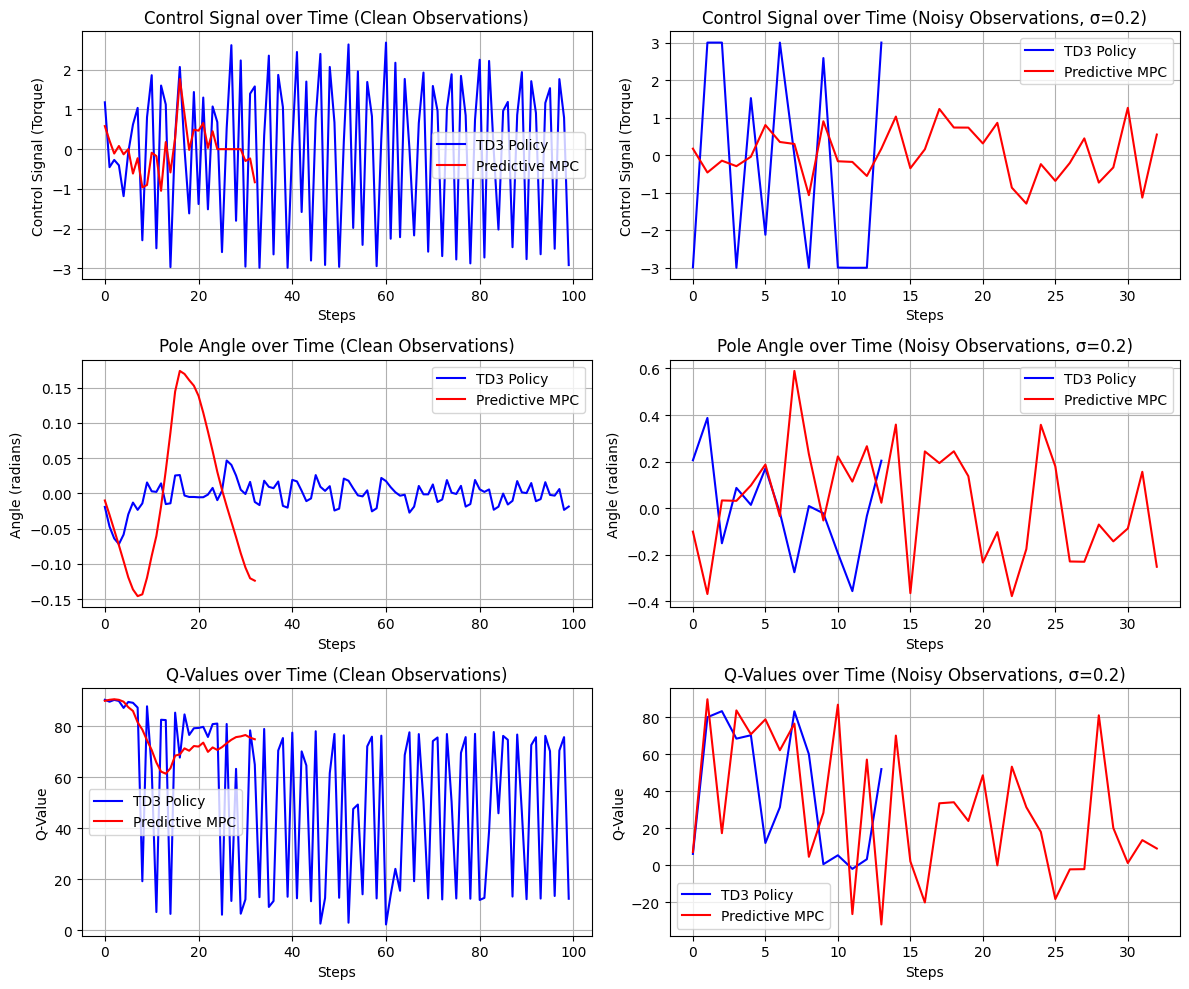


--- RESULTS SUMMARY ---
MPC Parameters: width=10, horizon=3, action_cost=10
Noise scale: 0.2

Clean Observations:
TD3 Policy:
  Mean Control Signal: -0.0161
  Std Control Signal: 1.8751
  Mean Q-Value: 52.2665
  Std Q-Value: 31.2742
  Mean Absolute Angle: 0.0145
  Episode Length: 100
Predictive MPC:
  Mean Control Signal: -0.0046
  Std Control Signal: 0.5504
  Mean Q-Value: 75.5652
  Std Q-Value: 8.2945
  Mean Absolute Angle: 0.0911
  Episode Length: 33

Noisy Observations:
TD3 Policy:
  Mean Control Signal: -0.2860
  Std Control Signal: 2.7027
  Mean Q-Value: 39.4982
  Std Q-Value: 33.2270
  Mean Absolute Angle: 0.1520
  Episode Length: 14
Predictive MPC:
  Mean Control Signal: 0.0398
  Std Control Signal: 0.6774
  Mean Q-Value: 30.2946
  Std Q-Value: 35.4653
  Mean Absolute Angle: 0.1966
  Episode Length: 33


In [62]:
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
import torch
from stable_baselines3 import TD3
import copy

# Custom wrapper that keeps original binary rewards but allows for noise
class BinaryRewardCartPole(gym.Wrapper):
    def __init__(self, env, add_noise=False, noise_scale=0.1):
        super().__init__(env)
        self.add_noise = add_noise
        self.noise_scale = noise_scale
        
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        
        # Add observation noise if enabled
        if self.add_noise:
            # Apply different noise levels to different elements
            # noise_scale for the first two elements (position, angle)
            # noise_scale*0.1 for the second two elements (velocities)
            noise = np.zeros_like(obs)
            noise[0:2] = np.random.normal(0, self.noise_scale, size=2)  # Position and angle
            noise[2:4] = np.random.normal(0, self.noise_scale*0.1, size=2)  # Velocities
            obs = obs + noise
        
        # Keep the original binary reward (typically +1 for each timestep)
        # No need to modify the reward logic
        
        return obs, reward, terminated, truncated, info
    
    def reset(self, **kwargs):
        obs, info = super().reset(**kwargs)
        
        # Add observation noise if enabled
        if self.add_noise:
            # Apply different noise levels to different elements
            noise = np.zeros_like(obs)
            noise[0:2] = np.random.normal(0, self.noise_scale, size=2)  # Position and angle
            noise[2:4] = np.random.normal(0, self.noise_scale*0.1, size=2)  # Velocities
            obs = obs + noise
            
        return obs, info

# Predictive Sampling MPC controller with corrected MuJoCo state management
class PredictiveSamplingMPC:
    def __init__(self, model, env, planning_width=10, n_planning=20, action_cost=0.01):
        self.model = model
        self.env = env
        self.planning_width = planning_width
        self.n_planning = n_planning
        self.action_cost = action_cost
        self.nominal_trajectory = np.zeros([n_planning, *env.action_space.shape])
    
    def evaluate_action_value(self, obs, action):
        critic_output = self.model.critic(
            torch.as_tensor(obs.reshape(1, -1), dtype=torch.float32),
            torch.as_tensor(action.reshape(1, -1), dtype=torch.float32)
        )
        
        # Handle the case where critic returns a tuple
        if isinstance(critic_output, tuple):
            q_value = critic_output[0]  # First element is the Q-value
        else:
            q_value = critic_output
            
        return q_value.detach().numpy()[0][0]
    
    def save_env_state(self, env):
        """Save MuJoCo state - corrected for gymnasium MuJoCo environments"""
        try:
            # For newer gymnasium MuJoCo environments
            if hasattr(env.unwrapped, 'model') and hasattr(env.unwrapped, 'data'):
                # This is the correct way for gymnasium MuJoCo
                qpos = env.unwrapped.data.qpos.copy()
                qvel = env.unwrapped.data.qvel.copy()
                time = env.unwrapped.data.time
                return {
                    'qpos': qpos,
                    'qvel': qvel, 
                    'time': time,
                    'type': 'mujoco_new'
                }
            else:
                print("Unknown environment type for state saving")
                return None
        except Exception as e:
            print(f"Error saving state: {e}")
            return None
    
    def restore_env_state(self, env, saved_state):
        """Restore MuJoCo state - corrected for gymnasium MuJoCo environments"""
        try:
            if saved_state is None:
                return False
                
            if saved_state['type'] == 'mujoco_new':
                # Restore positions and velocities
                env.unwrapped.data.qpos[:] = saved_state['qpos'].copy()
                env.unwrapped.data.qvel[:] = saved_state['qvel'].copy()
                env.unwrapped.data.time = saved_state['time']
                
                # Forward the simulation to update derived quantities
                import mujoco
                mujoco.mj_forward(env.unwrapped.model, env.unwrapped.data)
                return True
            else:
                return False
        except Exception as e:
            print(f"Error restoring state: {e}")
            return False
        
    def select_action(self, obs):
        # Save the current environment state BEFORE any planning
        initial_state = self.save_env_state(self.env)
        
        if initial_state is None:
            print("Warning: Could not save initial state, using policy fallback")
            action, _ = self.model.predict(obs, deterministic=True)
            return action
        
        # Shift the nominal trajectory forward
        if self.n_planning > 1:
            self.nominal_trajectory = np.vstack([
                self.nominal_trajectory[1:],
                np.zeros((1, *self.env.action_space.shape))
            ])
        
        # Initialize data structures
        actions = np.zeros([self.planning_width, self.n_planning, *self.env.action_space.shape])
        cumulative_reward = np.zeros(self.planning_width)
        
        # First candidate is the nominal trajectory
        actions[0] = self.nominal_trajectory
        
        # Generate noisy variations for other candidates
        noise_std = 0.1 * (self.env.action_space.high - self.env.action_space.low)
        for i in range(1, self.planning_width):
            noise = np.random.normal(0, noise_std, self.nominal_trajectory.shape)
            actions[i] = self.nominal_trajectory + noise
            actions[i] = np.clip(actions[i], self.env.action_space.low, self.env.action_space.high)
        
        # Evaluate all trajectories
        successful_evaluations = 0
        for i_trajectory in range(self.planning_width):
            # CRITICAL: Restore initial state before evaluating each trajectory
            success = self.restore_env_state(self.env, initial_state)
            if not success:
                print(f"Warning: Could not restore state for trajectory {i_trajectory}")
                cumulative_reward[i_trajectory] = -1000  # Heavy penalty
                continue
                
            current_obs = obs.copy()
            trajectory_reward = 0
            
            # Roll out this trajectory
            for step in range(self.n_planning):
                action = actions[i_trajectory, step]
                
                # Use the model to evaluate the action
                q_value = self.evaluate_action_value(current_obs, action)
                reward = q_value
                
                # Subtract the squared action cost
                reward -= self.action_cost * np.sum(np.square(action))
                
                trajectory_reward += reward
                
                # Use MuJoCo dynamics to get next state
                try:
                    next_obs, _, terminated, truncated, _ = self.env.step(action)
                    
                    # If episode would terminate, penalize this trajectory heavily
                    if terminated or truncated:
                        trajectory_reward -= 100  # Large penalty
                        break
                        
                    current_obs = next_obs
                except Exception as e:
                    print(f"Error during trajectory rollout step {step}: {e}")
                    trajectory_reward = -1000  # Heavy penalty
                    break
            
            cumulative_reward[i_trajectory] = trajectory_reward
            successful_evaluations += 1
        
        # CRITICAL: Restore the initial state after all planning is done
        final_restore = self.restore_env_state(self.env, initial_state)
        if not final_restore:
            print("Warning: Could not restore initial state after planning!")
        
        # Select best trajectory
        if successful_evaluations == 0:
            print("Warning: No successful trajectory evaluations, using policy fallback")
            action, _ = self.model.predict(obs, deterministic=True)
            return action
            
        best_trajectory = np.argmax(cumulative_reward)
        self.nominal_trajectory = actions[best_trajectory]
        
        print(f"Planning successful: {successful_evaluations}/{self.planning_width} trajectories evaluated")
        print(f"Best trajectory reward: {cumulative_reward[best_trajectory]:.3f}")
        
        return self.nominal_trajectory[0]

# Helper function to get Q-value for a given state-action pair
def get_q_value(model, obs, action):
    """Get Q-value for a given state-action pair"""
    try:
        critic_output = model.critic(
            torch.as_tensor(obs.reshape(1, -1), dtype=torch.float32),
            torch.as_tensor(action.reshape(1, -1), dtype=torch.float32)
        )
        
        # Handle the case where critic returns a tuple
        if isinstance(critic_output, tuple):
            q_value = critic_output[0]  # First element is the Q-value
        else:
            q_value = critic_output
            
        return q_value.detach().numpy()[0][0]
    except Exception as e:
        print(f"Error getting Q-value: {e}")
        return 0.0

# Test the state management directly
def test_state_management():
    """Test if state save/restore works correctly"""
    print("Testing state management...")
    
    env = BinaryRewardCartPole(gym.make("InvertedPendulum-v5"))
    obs, _ = env.reset()
    
    # Print environment structure info
    print(f"Environment type: {type(env.unwrapped)}")
    print(f"Has model: {hasattr(env.unwrapped, 'model')}")
    print(f"Has data: {hasattr(env.unwrapped, 'data')}")
    
    if hasattr(env.unwrapped, 'data'):
        print(f"qpos shape: {env.unwrapped.data.qpos.shape}")
        print(f"qvel shape: {env.unwrapped.data.qvel.shape}")
        print(f"Initial qpos: {env.unwrapped.data.qpos}")
        print(f"Initial qvel: {env.unwrapped.data.qvel}")
    
    # Test save/restore
    mpc = PredictiveSamplingMPC(None, env)  # No model needed for testing
    
    # Save initial state
    initial_state = mpc.save_env_state(env)
    print(f"State saved successfully: {initial_state is not None}")
    
    if initial_state:
        print(f"Saved state type: {initial_state.get('type', 'unknown')}")
    
    # Take a step
    action = env.action_space.sample()
    obs_after, _, _, _, _ = env.step(action)
    print(f"After step - qpos: {env.unwrapped.data.qpos}")
    
    # Restore state
    if initial_state:
        success = mpc.restore_env_state(env, initial_state)
        print(f"State restored successfully: {success}")
        print(f"After restore - qpos: {env.unwrapped.data.qpos}")

# Evaluation function with MPC parameters
def evaluate_controllers(model, max_steps=1000, noise_scale=0.05, planning_width=10, n_planning=50, action_cost=0.01):
    """Compare TD3 policy vs Predictive Sampling MPC with and without noise"""
    
    # First test state management
    test_state_management()
    
    results = {}
    
    # Test conditions
    conditions = [
        {"name": "clean", "add_noise": False},
        {"name": "noisy", "add_noise": True}
    ]
    
    for condition in conditions:
        print(f"\nEvaluating {condition['name']} condition...")
        
        # Create environments
        env_td3 = BinaryRewardCartPole(gym.make("InvertedPendulum-v5"), 
                                        add_noise=condition["add_noise"], 
                                        noise_scale=noise_scale)
        env_mpc = BinaryRewardCartPole(gym.make("InvertedPendulum-v5"), 
                                      add_noise=condition["add_noise"], 
                                      noise_scale=noise_scale)
        
        # Set the same random seed for consistent comparison
        seed = 42
        env_td3.reset(seed=seed)
        env_mpc.reset(seed=seed)
        
        # Initialize MPC controller with the provided parameters
        print(f"Initializing MPC with planning_width={planning_width}, n_planning={n_planning}")
        predictive_mpc = PredictiveSamplingMPC(model, env_mpc, 
                                              planning_width=planning_width, 
                                              n_planning=n_planning,
                                              action_cost=action_cost)
        
        # Storage for results
        td3_actions = []
        td3_angles = []
        td3_q_values = []
        mpc_actions = []
        mpc_angles = []
        mpc_q_values = []
        
        # Run simulation with TD3 policy
        print("Running TD3 simulation...")
        obs, _ = env_td3.reset(seed=seed)
        for i in range(max_steps):
            try:
                # Get action directly from the trained policy
                action, _ = model.predict(obs, deterministic=True)
                
                # Get Q-value for this state-action pair
                q_value = get_q_value(model, obs, action)
                
                obs, reward, terminated, truncated, _ = env_td3.step(action)
                td3_actions.append(action[0] if len(action) > 0 else action)
                td3_angles.append(obs[1])
                td3_q_values.append(q_value)
                
                if terminated or truncated:
                    break
            except Exception as e:
                print(f"Error in TD3 simulation at step {i}: {e}")
                break
        
        # Run simulation with predictive sampling MPC
        print("Running MPC simulation...")
        obs, _ = env_mpc.reset(seed=seed)
        for i in range(max_steps):
            try:
                action = predictive_mpc.select_action(obs)
                
                # Get Q-value for this state-action pair
                q_value = get_q_value(model, obs, action)
                
                obs, reward, terminated, truncated, _ = env_mpc.step(action)
                mpc_actions.append(action[0] if len(action) > 0 else action)
                mpc_angles.append(obs[1])
                mpc_q_values.append(q_value)
                
                if terminated or truncated:
                    print(f"MPC episode ended at step {i}")
                    break
                    
                if i % 50 == 0:  # Progress indicator
                    print(f"MPC step {i}, angle: {obs[1]:.4f}, action: {action[0]:.4f}")
                    
            except Exception as e:
                print(f"Error in MPC simulation at step {i}: {e}")
                break
        
        # Ensure we have data
        if len(mpc_actions) == 0:
            print("Warning: MPC produced no actions!")
            mpc_actions = [0.0]
            mpc_angles = [0.0]
            mpc_q_values = [0.0]
        
        # Store results for this condition
        results[condition["name"]] = {
            "td3": {
                "actions": td3_actions,
                "angles": td3_angles,
                "q_values": td3_q_values,
                "stats": {
                    "mean_action": np.mean(td3_actions) if td3_actions else 0,
                    "std_action": np.std(td3_actions) if td3_actions else 0,
                    "mean_angle": np.mean(np.abs(td3_angles)) if td3_angles else 0,
                    "max_angle": np.max(np.abs(td3_angles)) if td3_angles else 0,
                    "mean_q_value": np.mean(td3_q_values) if td3_q_values else 0,
                    "std_q_value": np.std(td3_q_values) if td3_q_values else 0,
                    "episode_length": len(td3_actions)
                }
            },
            "mpc": {
                "actions": mpc_actions,
                "angles": mpc_angles,
                "q_values": mpc_q_values,
                "stats": {
                    "mean_action": np.mean(mpc_actions) if mpc_actions else 0,
                    "std_action": np.std(mpc_actions) if mpc_actions else 0,
                    "mean_angle": np.mean(np.abs(mpc_angles)) if mpc_angles else 0,
                    "max_angle": np.max(np.abs(mpc_angles)) if mpc_angles else 0,
                    "mean_q_value": np.mean(mpc_q_values) if mpc_q_values else 0,
                    "std_q_value": np.std(mpc_q_values) if mpc_q_values else 0,
                    "episode_length": len(mpc_actions)
                }
            }
        }
    
    # Plot results - now with 3 rows
    fig, axes = plt.subplots(3, 2, figsize=(12, 10))
    
    # Clean condition plots
    clean_data = results["clean"]
    # Plot control signals - clean
    axes[0, 0].plot(clean_data["td3"]["actions"], label='TD3 Policy', color='blue')
    axes[0, 0].plot(clean_data["mpc"]["actions"], label='Predictive MPC', color='red')
    axes[0, 0].set_title('Control Signal over Time (Clean Observations)')
    axes[0, 0].set_xlabel('Steps')
    axes[0, 0].set_ylabel('Control Signal (Torque)')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Plot angles - clean
    axes[1, 0].plot(clean_data["td3"]["angles"], label='TD3 Policy', color='blue')
    axes[1, 0].plot(clean_data["mpc"]["angles"], label='Predictive MPC', color='red')
    axes[1, 0].set_title('Pole Angle over Time (Clean Observations)')
    axes[1, 0].set_xlabel('Steps')
    axes[1, 0].set_ylabel('Angle (radians)')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # Plot Q-values - clean
    axes[2, 0].plot(clean_data["td3"]["q_values"], label='TD3 Policy', color='blue')
    axes[2, 0].plot(clean_data["mpc"]["q_values"], label='Predictive MPC', color='red')
    axes[2, 0].set_title('Q-Values over Time (Clean Observations)')
    axes[2, 0].set_xlabel('Steps')
    axes[2, 0].set_ylabel('Q-Value')
    axes[2, 0].legend()
    axes[2, 0].grid(True)
    
    # Noisy condition plots
    noisy_data = results["noisy"]
    # Plot control signals - noisy
    axes[0, 1].plot(noisy_data["td3"]["actions"], label='TD3 Policy', color='blue')
    axes[0, 1].plot(noisy_data["mpc"]["actions"], label='Predictive MPC', color='red')
    axes[0, 1].set_title(f'Control Signal over Time (Noisy Observations, σ={noise_scale})')
    axes[0, 1].set_xlabel('Steps')
    axes[0, 1].set_ylabel('Control Signal (Torque)')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Plot angles - noisy
    axes[1, 1].plot(noisy_data["td3"]["angles"], label='TD3 Policy', color='blue')
    axes[1, 1].plot(noisy_data["mpc"]["angles"], label='Predictive MPC', color='red')
    axes[1, 1].set_title(f'Pole Angle over Time (Noisy Observations, σ={noise_scale})')
    axes[1, 1].set_xlabel('Steps')
    axes[1, 1].set_ylabel('Angle (radians)')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    # Plot Q-values - noisy
    axes[2, 1].plot(noisy_data["td3"]["q_values"], label='TD3 Policy', color='blue')
    axes[2, 1].plot(noisy_data["mpc"]["q_values"], label='Predictive MPC', color='red')
    axes[2, 1].set_title(f'Q-Values over Time (Noisy Observations, σ={noise_scale})')
    axes[2, 1].set_xlabel('Steps')
    axes[2, 1].set_ylabel('Q-Value')
    axes[2, 1].legend()
    axes[2, 1].grid(True)
    
    plt.tight_layout()
    plt.savefig('td3_vs_mpc_complete_analysis.png')
    plt.show()
    
    return results

# Main function
def train_and_compare_controllers(planning_width=10, n_planning=50, action_cost=0.01, noise_scale=0.05, max_steps=1000):
    """
    Train a TD3 model and compare it with MPC controller under different conditions.
    """
    # Create and train TD3 model or load it if already trained
    try:
        model = TD3.load("td3_cartpole_binary")
        print("Loaded existing model")
    except:
        print("Training new model...")
        env = BinaryRewardCartPole(gym.make("InvertedPendulum-v5"))
        model = TD3("MlpPolicy", env, verbose=1,
                    learning_rate=0.001,
                    buffer_size=100000,
                    learning_starts=10000,
                    batch_size=256,
                    gamma=0.99)
        model.learn(total_timesteps=100000)
        model.save("td3_cartpole_binary")
    
    # Run the evaluation with the specified MPC parameters
    results = evaluate_controllers(model, 
                                  max_steps=max_steps, 
                                  noise_scale=noise_scale, 
                                  planning_width=planning_width, 
                                  n_planning=n_planning, 
                                  action_cost=action_cost)
    
    # Display summary statistics
    print("\n--- RESULTS SUMMARY ---")
    print(f"MPC Parameters: width={planning_width}, horizon={n_planning}, action_cost={action_cost}")
    print(f"Noise scale: {noise_scale}")
    
    for condition in ["clean", "noisy"]:
        print(f"\n{condition.title()} Observations:")
        for controller in ["td3", "mpc"]:
            name = "TD3 Policy" if controller == "td3" else "Predictive MPC"
            stats = results[condition][controller]["stats"]
            print(f"{name}:")
            print(f"  Mean Control Signal: {stats['mean_action']:.4f}")
            print(f"  Std Control Signal: {stats['std_action']:.4f}")
            print(f"  Mean Q-Value: {stats['mean_q_value']:.4f}")
            print(f"  Std Q-Value: {stats['std_q_value']:.4f}")
            print(f"  Mean Absolute Angle: {stats['mean_angle']:.4f}")
            print(f"  Episode Length: {stats['episode_length']}")
    
    return results

# Example usage - now should work with large planning widths!
results = train_and_compare_controllers(
    planning_width=10,   # Start smaller to test
    n_planning=3,       # Planning horizon length
    action_cost=10,    # Action cost coefficient
    noise_scale=0.2,    # Observation noise scale
    max_steps=100       # Maximum steps per episode
)